In [21]:
#Name: Adiputra Bin Mohd Suki
#Student ID: SW01083729
#Name: Muhammad 'Ammar Bin Mohd Jailani
#Student ID: SW01083747


In [22]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

In [23]:
#download NLTK resources
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [25]:
#load dataset
df = pd.read_csv("reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [26]:
#check basic information
df.info()
df.shape
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [27]:
#combine necessary columns that are Summary, Score and Text
df = df[['Score', 'Summary', 'Text']].copy()
df['Summary'] = df['Summary'].fillna('')
df['Text'] = df['Text'].fillna('')
df['combined_text'] = df['Summary'] + " " + df['Text']

In [28]:
#Convert Ratings into Sentiment labels
def label_sentiment(score):
    if score in [1, 2]:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['Score'].apply(label_sentiment)
df[['Score', 'sentiment']].head()

,Score,sentiment
0,5,positive
1,1,negative
2,4,positive
3,2,negative
4,5,positive


In [29]:
#check class distribution
df['sentiment'].value_counts()

sentiment
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64

In [30]:
#use smaller sample first
df_sample = df.sample(n=30000, random_state=42)
df_sample = df_sample.reset_index(drop=True)

In [31]:
#clean text
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  
    text = re.sub(r'http\S+|www\S+', '', text)  
    text = re.sub(r'\d+', '', text)  
    text = text.translate(str.maketrans('', '', string.punctuation))  
    text = text.split()
    text = [word for word in text if word not in stop_words]
    return " ".join(text)

df_sample['clean_text'] = df_sample['combined_text'].apply(clean_text)

In [33]:
#check result
df_sample[['combined_text', 'clean_text']].head()

,combined_text,clean_text
0,Crunchy & Good Gluten-Free Sandwich Cookies! H...,crunchy good glutenfree sandwich cookies tried...
1,great kitty treats My cat loves these treats. ...,great kitty treats cat loves treats ever cant ...
2,COFFEE TASTE A little less than I expected. I...,coffee taste little less expected tends muddy ...
3,So the Mini-Wheats were too big? First there w...,miniwheats big first frosted miniwheats origin...
4,Great Taste . . . and I want to congratulate t...,great taste want congratulate graphic artist p...


In [34]:
#save extracted dataset
df_sample.to_csv("amazon_reviews_extracted.csv", index=False)

In [35]:
#split  train and test data
X = df_sample['clean_text']
y = df_sample['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
#Lexicon-based model: VADER
sia = SentimentIntensityAnalyzer()

def vader_label(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

vader_pred = X_test.apply(vader_label)

In [14]:
print("VADER Accuracy:", accuracy_score(y_test, vader_pred))
print(classification_report(y_test, vader_pred))

VADER Accuracy: 0.8083333333333333
              precision    recall  f1-score   support

    negative       0.64      0.35      0.45       861
     neutral       0.11      0.02      0.03       454
    positive       0.83      0.97      0.90      4685

    accuracy                           0.81      6000
   macro avg       0.53      0.45      0.46      6000
weighted avg       0.75      0.81      0.77      6000



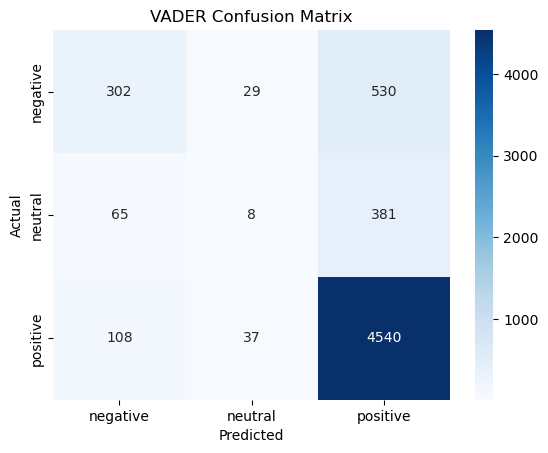

In [15]:
cm = confusion_matrix(y_test, vader_pred, labels=['negative', 'neutral', 'positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title("VADER Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
#Machine learning model 1: Bag of Words + Naive Bayes
bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

nb_pred = nb_model.predict(X_test_bow)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.8183333333333334
              precision    recall  f1-score   support

    negative       0.63      0.65      0.64       861
     neutral       0.30      0.37      0.33       454
    positive       0.92      0.89      0.91      4685

    accuracy                           0.82      6000
   macro avg       0.62      0.64      0.62      6000
weighted avg       0.83      0.82      0.82      6000



In [38]:
#Machine learning model 2: TF-IDF + Logistic Regression
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8583333333333333
              precision    recall  f1-score   support

    negative       0.75      0.60      0.67       861
     neutral       0.49      0.14      0.22       454
    positive       0.88      0.98      0.93      4685

    accuracy                           0.86      6000
   macro avg       0.71      0.57      0.60      6000
weighted avg       0.83      0.86      0.84      6000



In [39]:
#Machine learning model 3: TF-IDF + Linear SVM
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("Linear SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

Linear SVM Accuracy: 0.8558333333333333
              precision    recall  f1-score   support

    negative       0.70      0.65      0.68       861
     neutral       0.42      0.18      0.25       454
    positive       0.90      0.96      0.93      4685

    accuracy                           0.86      6000
   macro avg       0.67      0.60      0.62      6000
weighted avg       0.83      0.86      0.84      6000



In [19]:
results = pd.DataFrame({
    'Model': ['VADER', 'Naive Bayes + BoW', 'Logistic Regression + TF-IDF', 'Linear SVM + TF-IDF'],
    'Accuracy': [
        accuracy_score(y_test, vader_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

print(results.sort_values(by='Accuracy', ascending=False))

                          Model  Accuracy
2  Logistic Regression + TF-IDF  0.858333
3           Linear SVM + TF-IDF  0.855833
1             Naive Bayes + BoW  0.818333
0                         VADER  0.808333


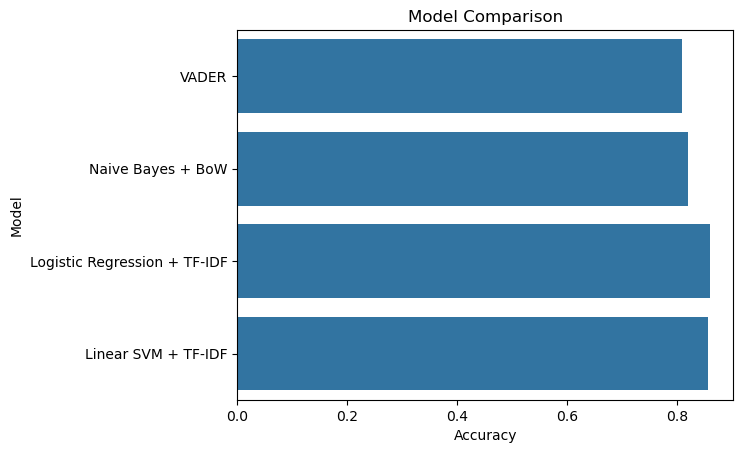

In [40]:
#Compare all models in one table
sns.barplot(data=results, x='Accuracy', y='Model')
plt.title("Model Comparison")
plt.show()